# Diffraction Stripe Angle Extraction — Interactive Dev

Paired with `angle_dev.py`.  Edit the `.py` file, re-run any cell — `%autoreload 2` reloads without a kernel restart.

**Workflow:**
1. Load data
2. Build shared feature image and inspect preprocessing stages
3. Run ensemble estimator and inspect candidates
4. Tune parameters in `angle_dev.py` and iterate

In [16]:
# Cell 1 — bootstrap
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

root = next(p for p in Path(".").resolve().parents if (p / "sim").is_dir())
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

print(f"Project root: {root}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Project root: C:\Users\bassd\Research\Drone\tele-img-sim


In [17]:
# Cell 2 — load data
import angle_dev
import numpy as np

FITS_PATH = root / "data" / "fuji6_asi178_100_15s.fit"

raw, stripe = angle_dev.load_and_preprocess(FITS_PATH)
print(f"raw:    {raw.shape}  [{raw.min():.3f}, {raw.max():.3f}]")
print(f"stripe: {stripe.shape}  [{stripe.min():.3f}, {stripe.max():.3f}]")

raw:    (2080, 3096)  [0.000, 1.000]
stripe: (2080, 3096)  [0.000, 0.710]


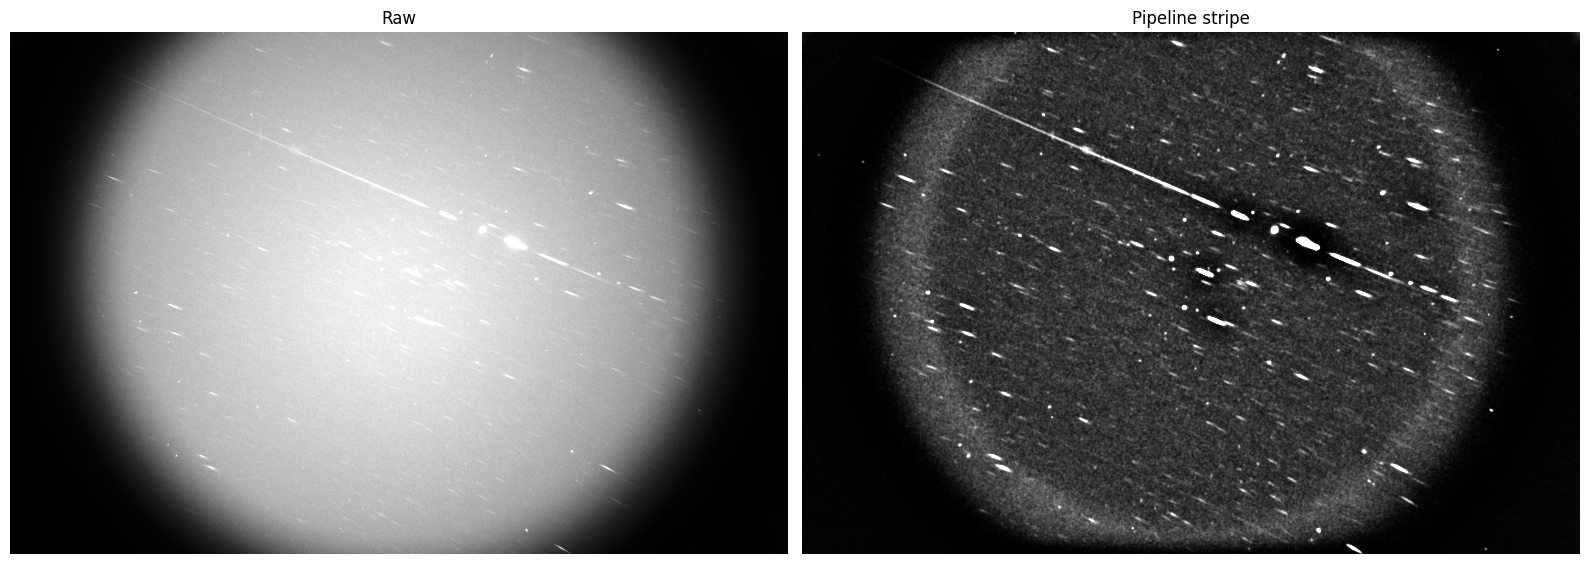

In [18]:
# Cell 3 — visualise raw vs pipeline stripe image
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, img, title in [(axes[0], raw, "Raw"), (axes[1], stripe, "Pipeline stripe")]:
    finite = img[np.isfinite(img)]
    vmin, vmax = np.percentile(finite, [0.5, 99.5])
    ax.imshow(img, origin="lower", cmap="gray", vmin=vmin, vmax=vmax)
    ax.set_title(title); ax.axis("off")
plt.tight_layout(); plt.show()

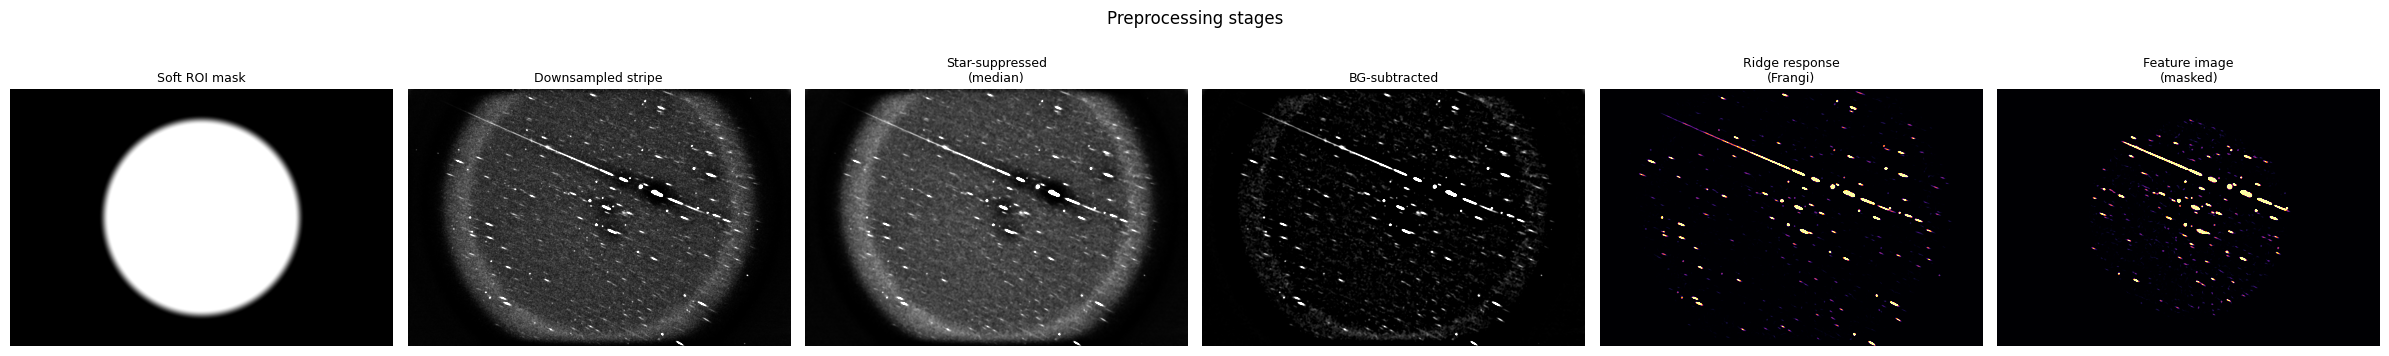

feature_img: (1040, 1548)  [0.0000, 0.7880]


In [19]:
# Cell 4 — build shared feature image and inspect preprocessing stages
# Tune parameters inside prepare_angle_feature_image() and re-run.
feature_img, dbg = angle_dev.prepare_angle_feature_image(stripe)
angle_dev.show_feature_debug(stripe, dbg)
print(f"feature_img: {feature_img.shape}  [{feature_img.min():.4f}, {feature_img.max():.4f}]")

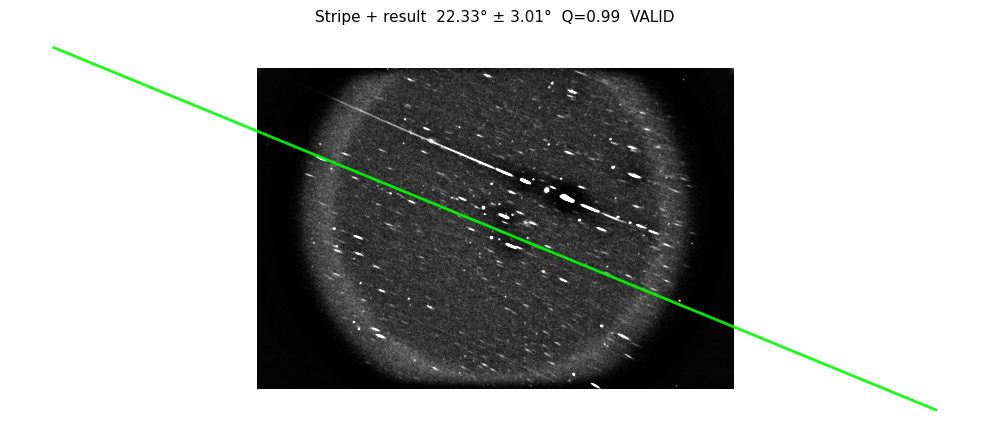

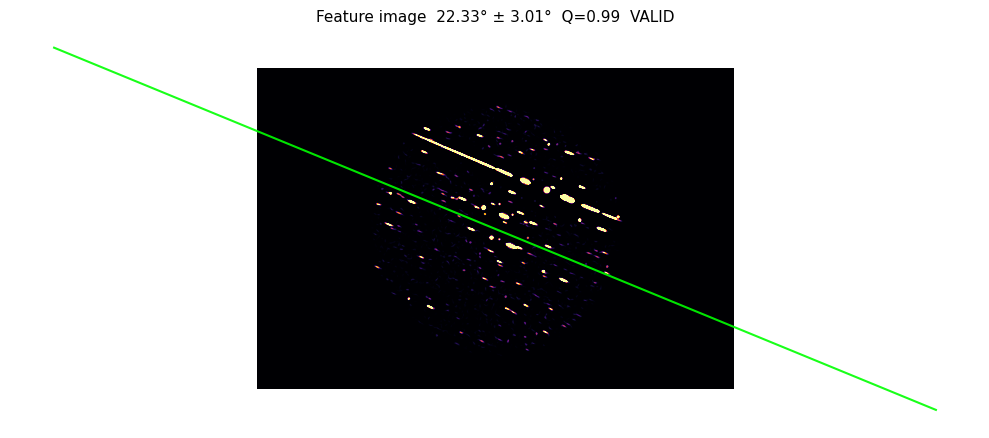

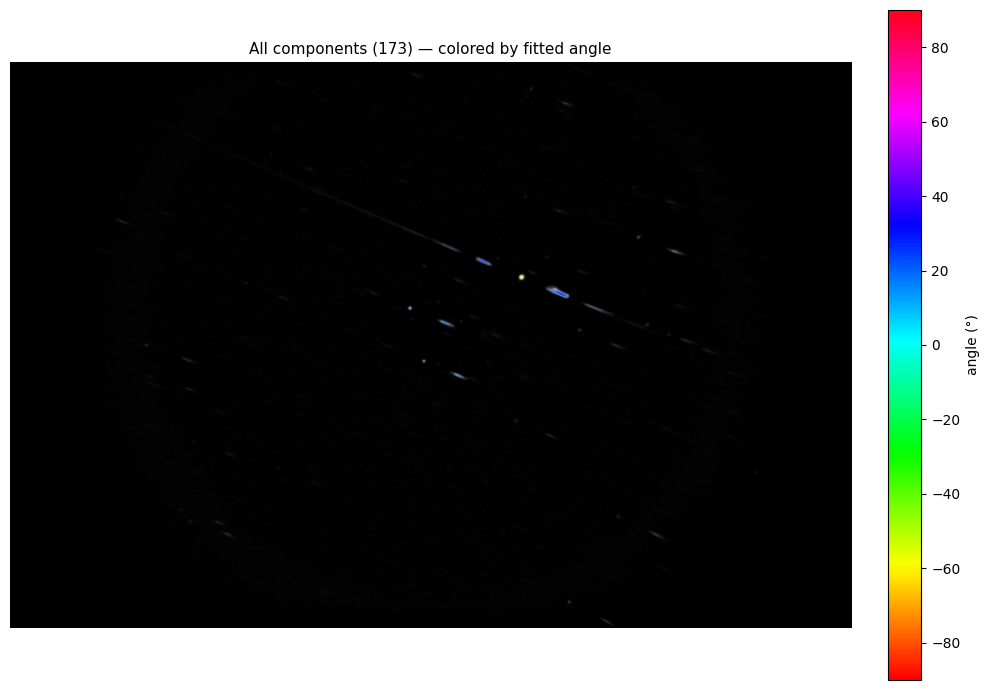

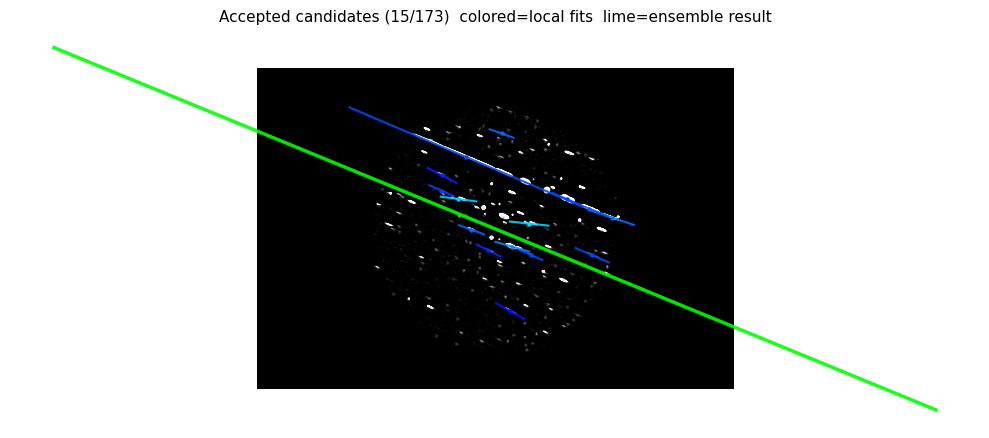

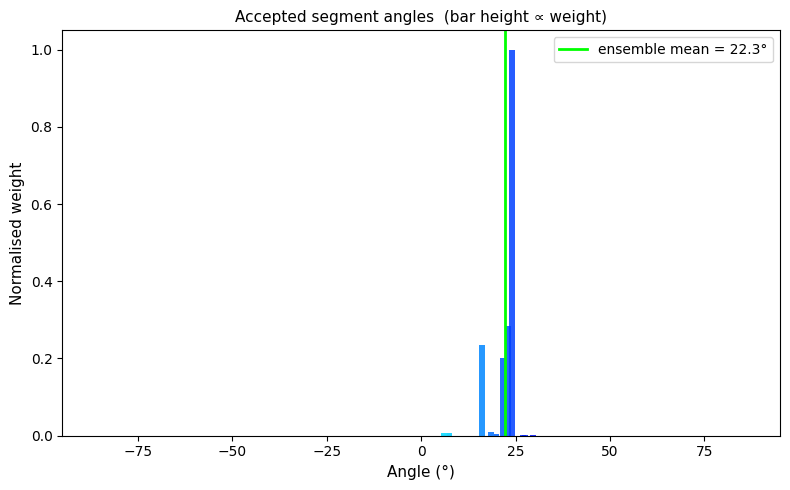

─── Ensemble estimator ───────────────────────────
  Detected components : 173
  Accepted (filtered) : 15
  Filter criteria     : min_major_length=40 px,  min_eccentricity=0.90

  angle   : 22.331 °
  σ       : 3.008 °
  quality : 0.995  (R · scale)
  valid   : YES

  Ensemble spread:
    min=6.01°  max=29.67°  raw std=6.46°
──────────────────────────────────────────────────
AngleEstimate(angle_deg=22.330535439850582, sigma_deg=3.0084743163081367, quality=0.9945283937891838, valid=True, method='ensemble')


In [31]:
# Cell 5 — run ensemble estimator and inspect
# Tune parameters here (or in measure_ensemble_lines / show_ensemble_debug) and re-run.

THRESHOLD_PCT   = 90.0   # percentile of nonzero feature values for binary threshold
MIN_PIXELS      = 40     # minimum component size
MIN_MAJOR_LEN   = 40.0   # minimum major axis length (px in feature_img domain)
MIN_ECCENTRICITY= 0.9   # 0=circle, 1=line; reject blobs below this

angle_dev.show_ensemble_debug(
    stripe, feature_img, dbg,
    threshold_pct=THRESHOLD_PCT,
    min_pixels=MIN_PIXELS,
    min_major_length=MIN_MAJOR_LEN,
    min_eccentricity=MIN_ECCENTRICITY,
)

est = angle_dev.measure_ensemble_lines(
    feature_img,
    threshold_pct=THRESHOLD_PCT,
    min_pixels=MIN_PIXELS,
    min_major_length=MIN_MAJOR_LEN,
    min_eccentricity=MIN_ECCENTRICITY,
)
print(est)

## Tuning guide

| Parameter | Effect | Tune when... |
|---|---|---|
| `THRESHOLD_PCT` | Controls which pixels enter components | Too many noise components → raise; stripe missed → lower |
| `MIN_PIXELS` | Minimum component size | Many tiny noise blobs → raise |
| `MIN_MAJOR_LEN` | Minimum segment length | Short spurious segments → raise |
| `MIN_ECCENTRICITY` | How elongated a segment must be (0–1) | Blobs contaminating result → raise |
| `ridge_sigmas` in `prepare_angle_feature_image` | Frangi scales (px) | Stripe not detected → bracket the expected stripe width |

## Next step: move to `measure/spikes.py` and `measure/preprocess.py`

Once results look correct:
1. `prepare_angle_feature_image` + helpers → `measure/preprocess.py`
2. `_extract_candidates`, `_filter_candidates`, `_weighted_axial_mean`, `_weighted_angle_sigma`, `measure_ensemble_lines` → `measure/spikes.py`
3. Replace `_measure_radon` / `_measure_hough` / `_measure_fourier` stubs with the ensemble approach
4. Run `measurement.ipynb` end-to-end to verify `SpikeMeasurementResult.image_angle_deg` is non-zero